In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual styles for our graphs
sns.set_theme(style="whitegrid")

In [5]:
# Define the file paths (assuming you named the folder ME5920_HW3)
weather_path = '/content/drive/MyDrive/ME5920_HW3/rsfweatherdata2011.csv'
energy_path = '/content/drive/MyDrive/ME5920_HW3/rsfmeasureddata2011.csv'

# Load the data into Pandas DataFrames
df_weather = pd.read_csv(weather_path)
df_energy = pd.read_csv(energy_path)

# Display the first 5 rows to make sure it worked
display(df_weather.head())
display(df_energy.head())

,DATE,HOUR-MST,Avg Global PSP (therm-zen cor) [W/m^2],Avg Global Photometric LI-210 [klux],Avg Global 90-South PSP [W/m^2],Avg Deck Dry Bulb Temp [deg C],Unnamed: 6,DATE AND TIME,Avg Deck Dry Bulb Temp [deg F],Avg Global Photometric LI-210 [fc],Ave Global Irradiance (W/ft2),Ave Global 90 South Irradiance (W/ft2)
0,1/1/2011,1.0,6.4653,0.0,-0.5478,-13.2307,NaN,1/1/11 1:00,8.18474,0.0,0.600647,-0.050892
1,1/1/2011,2.0,7.0470,0.0,-0.3776,-12.9523,NaN,1/1/11 2:00,8.68586,0.0,0.654688,-0.035080
2,1/1/2011,3.0,7.1437,0.0,-0.4596,-12.2292,NaN,1/1/11 3:00,9.98744,0.0,0.663672,-0.042698
3,1/1/2011,4.0,7.0436,0.0,-0.5842,-11.8457,NaN,1/1/11 4:00,10.67774,0.0,0.654372,-0.054274
4,1/1/2011,5.0,6.8356,0.0,-0.8721,-11.4127,NaN,1/1/11 5:00,11.45714,0.0,0.635049,-0.081021


,Day of Week,Date and Time,Total Cooling (kW),Total Heating (kW),Total Mechanical (kW),Total Lighting (kW),Total Plug Loads (kW),Total Data Center (kW),Total Building (kW),PV (kW),Building Net (kW),Unnamed: 11
0,Saturday,1/1/2011 0:00,0,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN
1,Saturday,1/1/2011 1:00,0,936,8.0,4.0,32.0,102.0,1080,0.0,1080.0,NaN
2,Saturday,1/1/2011 2:00,0,838,8.0,4.0,30.0,102.0,978,0.0,978.0,NaN
3,Saturday,1/1/2011 3:00,0,904,8.0,4.0,32.0,102.0,1046,0.0,1046.0,NaN
4,Saturday,1/1/2011 4:00,0,838,10.0,4.0,34.0,102.0,984,0.0,984.0,NaN


In [6]:
# 1. Convert both columns to datetime objects, forcing errors into NaT (Not a Time)
df_energy['Date and Time'] = pd.to_datetime(df_energy['Date and Time'], errors='coerce')
df_weather['DATE AND TIME'] = pd.to_datetime(df_weather['DATE AND TIME'], errors='coerce')

# 2. Drop the corrupted rows where the date became NaT
df_energy = df_energy.dropna(subset=['Date and Time'])
df_weather = df_weather.dropna(subset=['DATE AND TIME'])

# 3. Merge the datasets into one master dataframe where the times match
df_merged = pd.merge(df_energy, df_weather, left_on='Date and Time', right_on='DATE AND TIME', how='inner')

# 4. Drop the redundant second date column
df_merged = df_merged.drop(columns=['DATE AND TIME'])

# Check the shape to see how many rows and columns we have now
print(f"Merged Data Shape: {df_merged.shape}")
display(df_merged.head())

/tmp/ipykernel_3655/3161534330.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_weather['DATE AND TIME'] = pd.to_datetime(df_weather['DATE AND TIME'], errors='coerce')


Merged Data Shape: (8759, 23)


,Day of Week,Date and Time,Total Cooling (kW),Total Heating (kW),Total Mechanical (kW),Total Lighting (kW),Total Plug Loads (kW),Total Data Center (kW),Total Building (kW),PV (kW),...,HOUR-MST,Avg Global PSP (therm-zen cor) [W/m^2],Avg Global Photometric LI-210 [klux],Avg Global 90-South PSP [W/m^2],Avg Deck Dry Bulb Temp [deg C],Unnamed: 6,Avg Deck Dry Bulb Temp [deg F],Avg Global Photometric LI-210 [fc],Ave Global Irradiance (W/ft2),Ave Global 90 South Irradiance (W/ft2)
0,Saturday,2011-01-01 01:00:00,0,936,8.0,4.0,32.0,102.0,1080,0.0,...,1.0,6.4653,0.0,-0.5478,-13.2307,NaN,8.18474,0.0,0.600647,-0.050892
1,Saturday,2011-01-01 02:00:00,0,838,8.0,4.0,30.0,102.0,978,0.0,...,2.0,7.0470,0.0,-0.3776,-12.9523,NaN,8.68586,0.0,0.654688,-0.035080
2,Saturday,2011-01-01 03:00:00,0,904,8.0,4.0,32.0,102.0,1046,0.0,...,3.0,7.1437,0.0,-0.4596,-12.2292,NaN,9.98744,0.0,0.663672,-0.042698
3,Saturday,2011-01-01 04:00:00,0,838,10.0,4.0,34.0,102.0,984,0.0,...,4.0,7.0436,0.0,-0.5842,-11.8457,NaN,10.67774,0.0,0.654372,-0.054274
4,Saturday,2011-01-01 05:00:00,0,644,8.0,4.0,30.0,102.0,786,0.0,...,5.0,6.8356,0.0,-0.8721,-11.4127,NaN,11.45714,0.0,0.635049,-0.081021


In [7]:
# List of columns to drop (leakage, redundant weather, and junk columns from the CSV)
cols_to_drop = [
    'Total Cooling (kW)', 'Total Heating (kW)', 'Total Mechanical (kW)',
    'Total Lighting (kW)', 'Total Plug Loads (kW)', 'Total Data Center (kW)',
    'Building Net (kW)', 'Avg Deck Dry Bulb Temp [deg F]',
    'Ave Global Irradiance (W/ft2)', 'Ave Global 90 South Irradiance (W/ft2)',
    'Avg Global Photometric LI-210 [fc]', 'Day of Week',
    'DATE', 'HOUR-MST', 'Unnamed: 6', 'Unnamed: 11'
]

# Drop them safely (errors='ignore' ensures it won't crash if a column is already gone)
df_clean = df_merged.drop(columns=cols_to_drop, errors='ignore')

# Let's see our perfectly clean feature list!
print("Final Features for the Model:")
print(df_clean.columns.tolist())

Final Features for the Model:
['Date and Time', 'Total Building (kW)', 'PV (kW)', 'Avg Global PSP (therm-zen cor) [W/m^2]', 'Avg Global Photometric LI-210 [klux]', 'Avg Global 90-South PSP [W/m^2]', 'Avg Deck Dry Bulb Temp [deg C]']


In [8]:
from sklearn.preprocessing import MinMaxScaler

# Separate the time index (Date and Time) from the numbers
time_index = df_clean['Date and Time']
numeric_data = df_clean.drop(columns=['Date and Time'])

# FORCE all columns to be numeric. This turns the text note into a NaN (blank)
numeric_data = numeric_data.apply(pd.to_numeric, errors='coerce')

# Fill those newly created blanks with the value from the previous hour (forward-fill)
numeric_data = numeric_data.ffill().bfill()

# Initialize the scaler
scaler = MinMaxScaler(feature_range=(0, 1))

# Fit the scaler to our clean, strictly-numeric data and transform it
scaled_values = scaler.fit_transform(numeric_data)

# Put the scaled data back into a Pandas DataFrame
df_scaled = pd.DataFrame(scaled_values, columns=numeric_data.columns)

# Add the time column back so we don't lose track of our sequence
df_scaled.insert(0, 'Date and Time', time_index.values)

print(f"Scaled Data Shape: {df_scaled.shape}")
display(df_scaled.head())

Scaled Data Shape: (8759, 7)


,Date and Time,Total Building (kW),PV (kW),Avg Global PSP (therm-zen cor) [W/m^2],Avg Global Photometric LI-210 [klux],Avg Global 90-South PSP [W/m^2],Avg Deck Dry Bulb Temp [deg C]
0,2011-01-01 01:00:00,0.560865,0.994774,0.009392,0.0,0.987546,0.218770
1,2011-01-01 02:00:00,0.502844,0.994774,0.009939,0.0,0.987548,0.223353
2,2011-01-01 03:00:00,0.541524,0.994774,0.010029,0.0,0.987547,0.235258
3,2011-01-01 04:00:00,0.506257,0.994774,0.009935,0.0,0.987546,0.241571
4,2011-01-01 05:00:00,0.393629,0.994774,0.009740,0.0,0.987543,0.248700


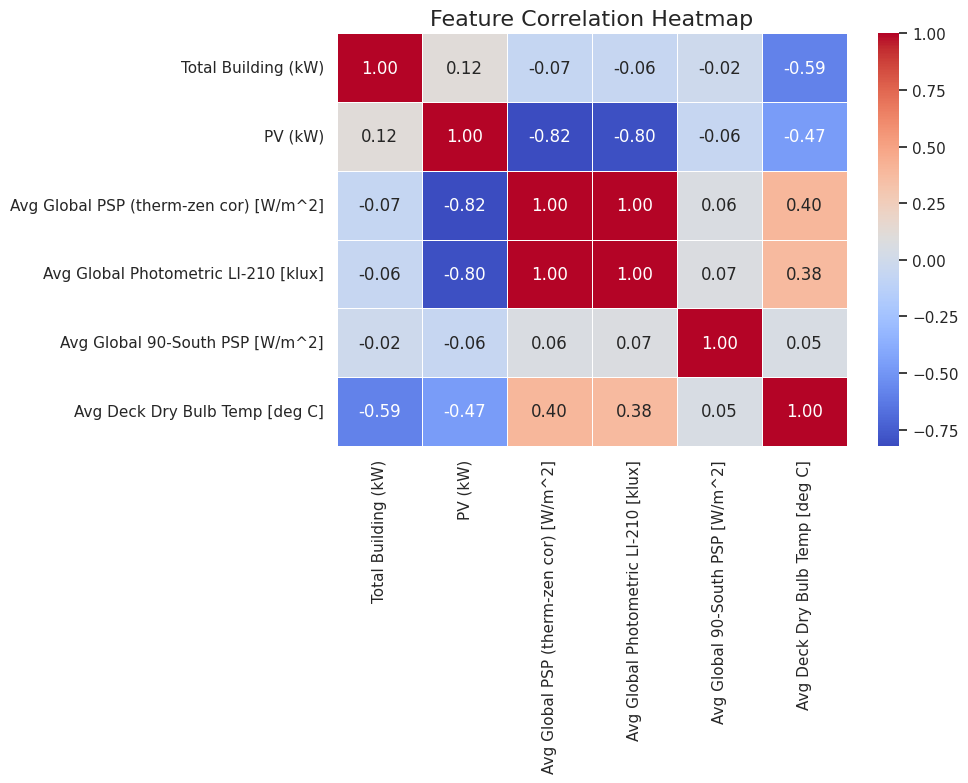

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# Using your specific dataset name: df_clean
corr_matrix = df_clean.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=16)
plt.tight_layout()
plt.show()

In [10]:
import numpy as np

# 1. Drop the datetime column (neural networks only want the numbers)
# Our columns are now:
# 0: Total Building, 1: PV, 2: Global PSP, 3: 90-South PSP, 4: Dry Bulb Temp
data_array = df_scaled.drop(columns=['Date and Time']).values

def create_sequences(data, lookback=168, horizon=24):
    X, y = [], []

    # Slide down the dataset, stopping before we run out of "future" hours
    for i in range(len(data) - lookback - horizon + 1):

        # Grab the past 168 hours for ALL 5 features
        window_x = data[i : i + lookback, :]

        # Grab the next 24 hours for ONLY the targets (Columns 0 and 1)
        window_y = data[i + lookback : i + lookback + horizon, 0:2]

        X.append(window_x)
        y.append(window_y)

    return np.array(X), np.array(y)

# 2. Run the function
lookback_window = 168  # 7 days of history
prediction_horizon = 24 # 1 day of future prediction

X, y = create_sequences(data_array, lookback=lookback_window, horizon=prediction_horizon)

print("--- Sequence Generation Complete ---")
print(f"X (Input) Shape:  {X.shape}  --> (Samples, Lookback Hours, Features)")
print(f"y (Target) Shape: {y.shape}   --> (Samples, Horizon Hours, Targets)")

--- Sequence Generation Complete ---
X (Input) Shape:  (8568, 168, 6)  --> (Samples, Lookback Hours, Features)
y (Target) Shape: (8568, 24, 2)   --> (Samples, Horizon Hours, Targets)


In [11]:
# Calculate where to slice the arrays
train_size = int(len(X) * 0.70)
val_size = int(len(X) * 0.15)

# Slice chronologically (NO SHUFFLING)
X_train, y_train = X[:train_size], y[:train_size]
X_val, y_val = X[train_size : train_size + val_size], y[train_size : train_size + val_size]
X_test, y_test = X[train_size + val_size:], y[train_size + val_size:]

print("--- Data Split Complete ---")
print(f"Training Samples:   {X_train.shape[0]}")
print(f"Validation Samples: {X_val.shape[0]}")
print(f"Testing Samples:    {X_test.shape[0]}")

--- Data Split Complete ---
Training Samples:   5997
Validation Samples: 1285
Testing Samples:    1286


In [12]:
import torch
from torch.utils.data import TensorDataset, DataLoader

# Set batch size (a good magic number for training stability)
BATCH_SIZE = 64

# Convert NumPy arrays to PyTorch Tensors (and force them to be 32-bit floats)
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)

# Create the DataLoaders
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=BATCH_SIZE, shuffle=False)

# Check if a GPU is available in Colab to make training 100x faster
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch DataLoaders Created!")
print(f"Using Device: {device}")

PyTorch DataLoaders Created!
Using Device: cuda


In [13]:
import torch.nn as nn

class Seq2Seq_MIMO(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, horizon):
        super(Seq2Seq_MIMO, self).__init__()
        self.horizon = horizon
        self.output_dim = output_dim

        # Encoder: Reads the 168 hours of weather/energy history
        # We will use GRU first, as it's faster than LSTM
        self.encoder = nn.GRU(input_dim, hidden_dim, batch_first=True)

        # Decoder: Predicts the 24 hours of future targets
        self.decoder = nn.GRU(output_dim, hidden_dim, batch_first=True)

        # Final layer to convert the hidden memory into the actual target values
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x, y_target=None, teacher_forcing_ratio=0.5):
        batch_size = x.size(0)

        # 1. Pass the 168-hour history through the Encoder
        _, hidden = self.encoder(x)

        # 2. Prepare the very first input for the Decoder (starting with zeros)
        decoder_input = torch.zeros(batch_size, 1, self.output_dim).to(x.device)

        # Prepare an empty tensor to store our 24 hours of predictions
        outputs = torch.zeros(batch_size, self.horizon, self.output_dim).to(x.device)

        # 3. Decode step-by-step (for 24 hours)
        for t in range(self.horizon):
            out, hidden = self.decoder(decoder_input, hidden)
            prediction = self.fc(out) # Our guess for hour 't'
            outputs[:, t:t+1, :] = prediction

            # TEACHER FORCING:
            # Sometimes feed the actual right answer to the next step so the model learns faster.
            # If no target is provided (like during testing), it must use its own prediction.
            if y_target is not None and torch.rand(1).item() < teacher_forcing_ratio:
                decoder_input = y_target[:, t:t+1, :] # The true answer
            else:
                decoder_input = prediction            # Its own guess

        return outputs

print("Seq2Seq Model Architecture Defined successfully!")

Seq2Seq Model Architecture Defined successfully!


In [14]:
import torch.optim as optim

# 1. Define the dimensions for our specific dataset
input_dimension = X_train_t.shape[2] # 6 features going in
hidden_dimension = 64 # A solid starting size for the model's "memory"
output_dimension = 2 # 2 targets coming out: Total Building & PV
prediction_horizon = 24 # 24 hours into the future

# 2. Instantiate the model and move it to the GPU
model = Seq2Seq_MIMO(
    input_dim=input_dimension,
    hidden_dim=hidden_dimension,
    output_dim=output_dimension,
    horizon=prediction_horizon
).to(device)

# 3. Setup the Optimizer and Loss Function
# Using the "magic number" learning rate suggested by your professor
learning_rate = 3e-4
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
criterion = nn.MSELoss() # Mean Squared Error (standard for predicting numbers)

# 4. The Training Loop
epochs = 20 # Let's train it for 20 rounds to start

print("Starting Training on Device:", device)
for epoch in range(epochs):
    # -- TRAINING PHASE --
    model.train() # Tell the model it's time to learn
    train_loss = 0.0

    for batch_X, batch_y in train_loader:
        # Move data to GPU
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)

        # Clear old gradients
        optimizer.zero_grad()

        # Forward Pass (Make a guess, using teacher forcing 50% of the time)
        outputs = model(batch_X, batch_y, teacher_forcing_ratio=0.5)

        # Calculate how wrong the guess was
        loss = criterion(outputs, batch_y)

        # Backward Pass (Learn from the mistake)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    # -- VALIDATION PHASE --
    model.eval() # Tell the model to stop learning and just take a test
    val_loss = 0.0

    with torch.no_grad(): # Don't track gradients during validation (saves memory)
        for batch_X, batch_y in val_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)

            # Make a guess (NO teacher forcing allowed on the test!)
            outputs = model(batch_X, teacher_forcing_ratio=0.0)
            loss = criterion(outputs, batch_y)
            val_loss += loss.item()

    # Calculate average losses for this epoch
    train_loss_avg = train_loss / len(train_loader)
    val_loss_avg = val_loss / len(val_loader)

    # Print progress every 5 epochs (and the first one)
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {train_loss_avg:.5f} | Validation Loss: {val_loss_avg:.5f}")

print("--- Training Complete! ---")

Starting Training on Device: cuda
Epoch [1/20] | Train Loss: 0.13400 | Validation Loss: 0.01829
Epoch [5/20] | Train Loss: 0.01268 | Validation Loss: 0.01642
Epoch [10/20] | Train Loss: 0.00554 | Validation Loss: 0.00836
Epoch [15/20] | Train Loss: 0.00371 | Validation Loss: 0.00656
Epoch [20/20] | Train Loss: 0.00319 | Validation Loss: 0.00628
--- Training Complete! ---


In [15]:
import torch.optim as optim
import torch.nn as nn

# 1. Define the dimensions for our specific dataset
input_dimension = X_train_t.shape[2] # 6 features going in
hidden_dimension = 64 # A solid starting size for the model's "memory"
output_dimension = 2 # 2 targets coming out: Total Building & PV
prediction_horizon = 24 # 24 hours into the future

# 2. Instantiate the model and move it to the GPU
model = Seq2Seq_MIMO(
    input_dim=input_dimension,
    hidden_dim=hidden_dimension,
    output_dim=output_dimension,
    horizon=prediction_horizon
).to(device)

# 3. Setup the Optimizer and Loss Function
# Using the "magic number" learning rate suggested by your professor
learning_rate = 3e-4
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
criterion = nn.MSELoss() # Mean Squared Error (standard for predicting numbers)

# 4. The Training Loop
epochs = 20 # Let's train it for 20 rounds to start

print("Starting Training on Device:", device)
for epoch in range(epochs):
    # -- TRAINING PHASE --
    model.train() # Tell the model it's time to learn
    train_loss = 0.0

    for batch_X, batch_y in train_loader:
        # Move data to GPU
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)

        # Clear old gradients
        optimizer.zero_grad()

        # Forward Pass (Make a guess, using teacher forcing 50% of the time)
        outputs = model(batch_X, batch_y, teacher_forcing_ratio=0.5)

        # Calculate how wrong the guess was
        loss = criterion(outputs, batch_y)

        # Backward Pass (Learn from the mistake)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    # -- VALIDATION PHASE --
    model.eval() # Tell the model to stop learning and just take a test
    val_loss = 0.0

    with torch.no_grad(): # Don't track gradients during validation (saves memory)
        for batch_X, batch_y in val_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)

            # Make a guess (NO teacher forcing allowed on the test!)
            outputs = model(batch_X, teacher_forcing_ratio=0.0)
            loss = criterion(outputs, batch_y)
            val_loss += loss.item()

    # Calculate average losses for this epoch
    train_loss_avg = train_loss / len(train_loader)
    val_loss_avg = val_loss / len(val_loader)

    # Print progress every 5 epochs (and the first one)
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {train_loss_avg:.5f} | Validation Loss: {val_loss_avg:.5f}")

print("--- Training Complete! ---")

Starting Training on Device: cuda
Epoch [1/20] | Train Loss: 0.13846 | Validation Loss: 0.01845
Epoch [5/20] | Train Loss: 0.01176 | Validation Loss: 0.01637
Epoch [10/20] | Train Loss: 0.00539 | Validation Loss: 0.00841
Epoch [15/20] | Train Loss: 0.00393 | Validation Loss: 0.00720
Epoch [20/20] | Train Loss: 0.00331 | Validation Loss: 0.00598
--- Training Complete! ---


In [16]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. Put the model in test mode
model.eval()

predictions = []
actuals = []

# 2. Run the test data through the model
with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)

        # NO teacher forcing during testing! It must predict on its own.
        outputs = model(batch_X, teacher_forcing_ratio=0.0)

        predictions.append(outputs.cpu().numpy())
        actuals.append(batch_y.numpy())

# Group the batches back into solid arrays
predictions = np.concatenate(predictions, axis=0)
actuals = np.concatenate(actuals, axis=0)

# 3. The Un-Scaling Process (Inverse Transform)
# We flatten the arrays to 2D so our original scaler can understand them
pred_2d = predictions.reshape(-1, 2)
actuals_2d = actuals.reshape(-1, 2)

# CREATE DUMMY COLUMNS FOR THE 6 ORIGINAL FEATURES (This fixes the error!)
dummy_pred = np.zeros((len(pred_2d), 6))
dummy_pred[:, 0:2] = pred_2d
pred_unscaled = scaler.inverse_transform(dummy_pred)[:, 0:2] # Extract just the kW targets

dummy_act = np.zeros((len(actuals_2d), 6))
dummy_act[:, 0:2] = actuals_2d
actuals_unscaled = scaler.inverse_transform(dummy_act)[:, 0:2]

# 4. Calculate and Print the Required Metrics
target_names = ['Total Building (kW)', 'PV (kW)']

for i, name in enumerate(target_names):
    y_true = actuals_unscaled[:, i]
    y_pred = pred_unscaled[:, i]

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    mean_true = np.mean(y_true)
    cvrmse = (rmse / mean_true) * 100 if mean_true != 0 else 0

    print(f"\n--- Metrics for {name} ---")
    print(f"RMSE:      {rmse:.2f} kW")
    print(f"MAE:       {mae:.2f} kW")
    print(f"R-squared: {r2:.4f}")
    print(f"CVRMSE:    {cvrmse:.2f}%")


--- Metrics for Total Building (kW) ---
RMSE:      122.50 kW
MAE:       91.44 kW
R-squared: 0.1137
CVRMSE:    39.41%

--- Metrics for PV (kW) ---
RMSE:      114.22 kW
MAE:       70.83 kW
R-squared: 0.5100
CVRMSE:    -147.93%


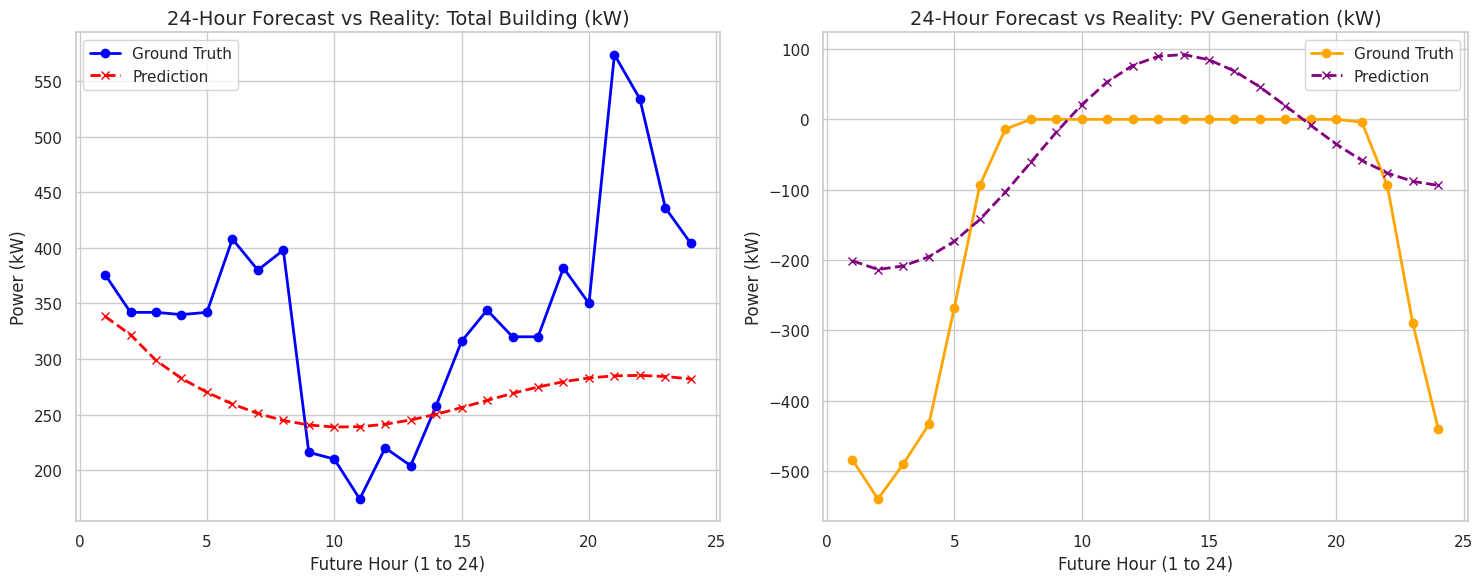

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Grab the very first 24-hour sequence from our unscaled results
true_building = actuals_unscaled[:24, 0]
pred_building = pred_unscaled[:24, 0]

true_pv = actuals_unscaled[:24, 1]
pred_pv = pred_unscaled[:24, 1]

hours = range(1, 25)

# Set up the visual canvas
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 6))

# Plot 1: Total Building (kW)
plt.subplot(1, 2, 1)
plt.plot(hours, true_building, label='Ground Truth', marker='o', color='blue', linewidth=2)
plt.plot(hours, pred_building, label='Prediction', marker='x', linestyle='--', color='red', linewidth=2)
plt.title('24-Hour Forecast vs Reality: Total Building (kW)', fontsize=14)
plt.xlabel('Future Hour (1 to 24)', fontsize=12)
plt.ylabel('Power (kW)', fontsize=12)
plt.legend()

# Plot 2: PV Generation (kW)
plt.subplot(1, 2, 2)
plt.plot(hours, true_pv, label='Ground Truth', marker='o', color='orange', linewidth=2)
plt.plot(hours, pred_pv, label='Prediction', marker='x', linestyle='--', color='purple', linewidth=2)
plt.title('24-Hour Forecast vs Reality: PV Generation (kW)', fontsize=14)
plt.xlabel('Future Hour (1 to 24)', fontsize=12)
plt.ylabel('Power (kW)', fontsize=12)
plt.legend()

plt.tight_layout()
plt.show()

In [18]:
import torch.nn as nn
import torch

class Seq2Seq_MIMO_LSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, horizon):
        super(Seq2Seq_MIMO_LSTM, self).__init__()
        self.horizon = horizon
        self.output_dim = output_dim
        self.hidden_dim = hidden_dim

        # Encoder: Using LSTM instead of GRU
        self.encoder = nn.LSTM(input_dim, hidden_dim, batch_first=True)

        # Decoder: Using LSTM instead of GRU
        self.decoder = nn.LSTM(output_dim, hidden_dim, batch_first=True)

        # Final layer
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x, y_target=None, teacher_forcing_ratio=0.5):
        batch_size = x.size(0)

        # 1. Pass history through the Encoder
        # LSTM returns the output, PLUS a tuple containing (hidden_state, cell_state)
        _, (hidden, cell) = self.encoder(x)

        # 2. Prepare first input for Decoder
        decoder_input = torch.zeros(batch_size, 1, self.output_dim).to(x.device)
        outputs = torch.zeros(batch_size, self.horizon, self.output_dim).to(x.device)

        # 3. Decode step-by-step
        for t in range(self.horizon):
            # We must pass BOTH the hidden and cell states into the decoder
            out, (hidden, cell) = self.decoder(decoder_input, (hidden, cell))
            prediction = self.fc(out)
            outputs[:, t:t+1, :] = prediction

            # Teacher Forcing
            if y_target is not None and torch.rand(1).item() < teacher_forcing_ratio:
                decoder_input = y_target[:, t:t+1, :]
            else:
                decoder_input = prediction

        return outputs

print("Seq2Seq LSTM Architecture Defined successfully!")

Seq2Seq LSTM Architecture Defined successfully!


In [ ]:
import torch.optim as optim
import torch.nn as nn

# 1. Instantiate the NEW LSTM model and move it to the GPU
# We call it 'lstm_model' so it doesn't overwrite your finished GRU model
lstm_model = Seq2Seq_MIMO_LSTM(
    input_dim=input_dimension,
    hidden_dim=hidden_dimension,
    output_dim=output_dimension,
    horizon=prediction_horizon
).to(device)

# 2. Setup the Optimizer and Loss Function
optimizer_lstm = optim.Adam(lstm_model.parameters(), lr=learning_rate)
criterion_lstm = nn.MSELoss()

# 3. The Training Loop
epochs = 20

print("Starting LSTM Training on Device:", device)
for epoch in range(epochs):
    # -- TRAINING PHASE --
    lstm_model.train()
    train_loss = 0.0

    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)

        optimizer_lstm.zero_grad()

        outputs = lstm_model(batch_X, batch_y, teacher_forcing_ratio=0.5)
        loss = criterion_lstm(outputs, batch_y)

        loss.backward()
        optimizer_lstm.step()
        train_loss += loss.item()

    # -- VALIDATION PHASE --
    lstm_model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)

            outputs = lstm_model(batch_X, teacher_forcing_ratio=0.0)
            loss = criterion_lstm(outputs, batch_y)
            val_loss += loss.item()

    train_loss_avg = train_loss / len(train_loader)
    val_loss_avg = val_loss / len(val_loader)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {train_loss_avg:.5f} | Validation Loss: {val_loss_avg:.5f}")

print("--- LSTM Training Complete! ---")

Starting LSTM Training on Device: cuda
Epoch [1/20] | Train Loss: 0.24471 | Validation Loss: 0.02042
Epoch [5/20] | Train Loss: 0.01474 | Validation Loss: 0.01825
Epoch [10/20] | Train Loss: 0.00593 | Validation Loss: 0.00878


In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Put the LSTM model in test mode
lstm_model.eval()

predictions = []
actuals = []

# 2. Run the test data
with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)
        outputs = lstm_model(batch_X, teacher_forcing_ratio=0.0)
        predictions.append(outputs.cpu().numpy())
        actuals.append(batch_y.numpy())

predictions = np.concatenate(predictions, axis=0)
actuals = np.concatenate(actuals, axis=0)

pred_2d = predictions.reshape(-1, 2)
actuals_2d = actuals.reshape(-1, 2)

# 3. The Un-Scaling Process
dummy_pred = np.zeros((len(pred_2d), 6))
dummy_pred[:, 0:2] = pred_2d
pred_unscaled = scaler.inverse_transform(dummy_pred)[:, 0:2]

dummy_act = np.zeros((len(actuals_2d), 6))
dummy_act[:, 0:2] = actuals_2d
actuals_unscaled = scaler.inverse_transform(dummy_act)[:, 0:2]

# 4. Calculate Metrics
target_names = ['Total Building (kW)', 'PV (kW)']
for i, name in enumerate(target_names):
    y_true = actuals_unscaled[:, i]
    y_pred = pred_unscaled[:, i]

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mean_true = np.mean(y_true)
    cvrmse = (rmse / mean_true) * 100 if mean_true != 0 else 0

    print(f"\n--- LSTM Metrics for {name} ---")
    print(f"RMSE:      {rmse:.2f} kW")
    print(f"MAE:       {mae:.2f} kW")
    print(f"R-squared: {r2:.4f}")
    print(f"CVRMSE:    {cvrmse:.2f}%")

# 5. Visual Plots
true_building = actuals_unscaled[:24, 0]
pred_building = pred_unscaled[:24, 0]
true_pv = actuals_unscaled[:24, 1]
pred_pv = pred_unscaled[:24, 1]
hours = range(1, 25)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
plt.plot(hours, true_building, label='Ground Truth', marker='o', color='blue', linewidth=2)
plt.plot(hours, pred_building, label='LSTM Prediction', marker='x', linestyle='--', color='red', linewidth=2)
plt.title('LSTM: Total Building (kW)', fontsize=14)
plt.xlabel('Future Hour (1 to 24)', fontsize=12)
plt.ylabel('Power (kW)', fontsize=12)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(hours, true_pv, label='Ground Truth', marker='o', color='orange', linewidth=2)
plt.plot(hours, pred_pv, label='LSTM Prediction', marker='x', linestyle='--', color='purple', linewidth=2)
plt.title('LSTM: PV Generation (kW)', fontsize=14)
plt.xlabel('Future Hour (1 to 24)', fontsize=12)
plt.ylabel('Power (kW)', fontsize=12)
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# 1. Slice the target tensors to keep ONLY the first column (Total Building)
# We use 0:1 to keep the math dimensions 3D (Samples, Horizon, 1 Feature)
y_train_bldg = y_train_t[:, :, 0:1]
y_val_bldg = y_val_t[:, :, 0:1]
y_test_bldg = y_test_t[:, :, 0:1]

# 2. Create the new MISO DataLoaders
train_loader_bldg = DataLoader(TensorDataset(X_train_t, y_train_bldg), batch_size=BATCH_SIZE, shuffle=True)
val_loader_bldg = DataLoader(TensorDataset(X_val_t, y_val_bldg), batch_size=BATCH_SIZE, shuffle=False)
test_loader_bldg = DataLoader(TensorDataset(X_test_t, y_test_bldg), batch_size=BATCH_SIZE, shuffle=False)

print("MISO DataLoaders for Total Building created!")

In [ ]:
# 1. Set output to 1 target
output_dimension_miso = 1

# 2. Instantiate the GRU model for MISO
miso_gru_bldg = Seq2Seq_MIMO(
    input_dim=input_dimension,
    hidden_dim=hidden_dimension,
    output_dim=output_dimension_miso,
    horizon=prediction_horizon
).to(device)

optimizer_miso = optim.Adam(miso_gru_bldg.parameters(), lr=learning_rate)
criterion_miso = nn.MSELoss()

# 3. Train!
epochs = 20
print("Starting MISO GRU (Total Building) Training...")

for epoch in range(epochs):
    miso_gru_bldg.train()
    train_loss = 0.0

    # USE THE NEW BLDG DATALOADER
    for batch_X, batch_y in train_loader_bldg:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)

        optimizer_miso.zero_grad()
        outputs = miso_gru_bldg(batch_X, batch_y, teacher_forcing_ratio=0.5)
        loss = criterion_miso(outputs, batch_y)
        loss.backward()
        optimizer_miso.step()
        train_loss += loss.item()

    miso_gru_bldg.eval()
    val_loss = 0.0

    with torch.no_grad():
        # USE THE NEW BLDG DATALOADER
        for batch_X, batch_y in val_loader_bldg:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            outputs = miso_gru_bldg(batch_X, teacher_forcing_ratio=0.0)
            loss = criterion_miso(outputs, batch_y)
            val_loss += loss.item()

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {train_loss/len(train_loader_bldg):.5f} | Val Loss: {val_loss/len(val_loader_bldg):.5f}")

print("--- MISO GRU (Building) Training Complete! ---")

In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Put the MISO model in test mode
miso_gru_bldg.eval()

predictions = []
actuals = []

# 2. Run the test data
with torch.no_grad():
    for batch_X, batch_y in test_loader_bldg:
        batch_X = batch_X.to(device)
        outputs = miso_gru_bldg(batch_X, teacher_forcing_ratio=0.0)
        predictions.append(outputs.cpu().numpy())
        actuals.append(batch_y.numpy())

predictions = np.concatenate(predictions, axis=0).reshape(-1, 1)
actuals = np.concatenate(actuals, axis=0).reshape(-1, 1)

# 3. The Un-Scaling Process (For just 1 Target)
dummy_pred = np.zeros((len(predictions), 6))
dummy_pred[:, 0] = predictions[:, 0] # Place predictions in the 'Building' column
pred_unscaled = scaler.inverse_transform(dummy_pred)[:, 0]

dummy_act = np.zeros((len(actuals), 6))
dummy_act[:, 0] = actuals[:, 0]
actuals_unscaled = scaler.inverse_transform(dummy_act)[:, 0]

# 4. Calculate Metrics
y_true = actuals_unscaled
y_pred = pred_unscaled

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)
mean_true = np.mean(y_true)
cvrmse = (rmse / mean_true) * 100 if mean_true != 0 else 0

print("\n--- MISO GRU Metrics for Total Building (kW) ---")
print(f"RMSE:      {rmse:.2f} kW")
print(f"MAE:       {mae:.2f} kW")
print(f"R-squared: {r2:.4f}")
print(f"CVRMSE:    {cvrmse:.2f}%")

# 5. Visual Plot
hours = range(1, 25)
true_building = actuals_unscaled[:24]
pred_building = pred_unscaled[:24]

sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 6))

plt.plot(hours, true_building, label='Ground Truth', marker='o', color='blue', linewidth=2)
plt.plot(hours, pred_building, label='MISO GRU Prediction', marker='x', linestyle='--', color='red', linewidth=2)
plt.title('MISO GRU: Total Building (kW)', fontsize=14)
plt.xlabel('Future Hour (1 to 24)', fontsize=12)
plt.ylabel('Power (kW)', fontsize=12)
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# 1. Slice the target tensors to keep ONLY the second column (PV generation)
y_train_pv = y_train_t[:, :, 1:2]
y_val_pv = y_val_t[:, :, 1:2]
y_test_pv = y_test_t[:, :, 1:2]

# 2. Create the PV DataLoaders
train_loader_pv = DataLoader(TensorDataset(X_train_t, y_train_pv), batch_size=BATCH_SIZE, shuffle=True)
val_loader_pv = DataLoader(TensorDataset(X_val_t, y_val_pv), batch_size=BATCH_SIZE, shuffle=False)
test_loader_pv = DataLoader(TensorDataset(X_test_t, y_test_pv), batch_size=BATCH_SIZE, shuffle=False)

# 3. Instantiate the GRU model for PV
miso_gru_pv = Seq2Seq_MIMO(
    input_dim=input_dimension,
    hidden_dim=hidden_dimension,
    output_dim=1, # 1 target
    horizon=prediction_horizon
).to(device)

optimizer_pv = optim.Adam(miso_gru_pv.parameters(), lr=learning_rate)
criterion_pv = nn.MSELoss()

# 4. Train!
epochs = 20
print("Starting MISO GRU (PV) Training...")

for epoch in range(epochs):
    miso_gru_pv.train()
    train_loss = 0.0

    for batch_X, batch_y in train_loader_pv:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)

        optimizer_pv.zero_grad()
        outputs = miso_gru_pv(batch_X, batch_y, teacher_forcing_ratio=0.5)
        loss = criterion_pv(outputs, batch_y)
        loss.backward()
        optimizer_pv.step()
        train_loss += loss.item()

    miso_gru_pv.eval()
    val_loss = 0.0

    with torch.no_grad():
        for batch_X, batch_y in val_loader_pv:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            outputs = miso_gru_pv(batch_X, teacher_forcing_ratio=0.0)
            loss = criterion_pv(outputs, batch_y)
            val_loss += loss.item()

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {train_loss/len(train_loader_pv):.5f} | Val Loss: {val_loss/len(val_loader_pv):.5f}")

print("--- MISO GRU (PV) Training Complete! ---")

In [ ]:
# 1. Instantiate the MISO LSTM model for Building
miso_lstm_bldg = Seq2Seq_MIMO_LSTM(
    input_dim=input_dimension,
    hidden_dim=hidden_dimension,
    output_dim=1,
    horizon=prediction_horizon
).to(device)

optimizer_miso_lstm_bldg = optim.Adam(miso_lstm_bldg.parameters(), lr=learning_rate)
criterion = nn.MSELoss()

# 2. Train the Model
epochs = 20
print("Starting MISO LSTM (Total Building) Training...")

for epoch in range(epochs):
    miso_lstm_bldg.train()
    train_loss = 0.0
    for batch_X, batch_y in train_loader_bldg:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        optimizer_miso_lstm_bldg.zero_grad()
        outputs = miso_lstm_bldg(batch_X, batch_y, teacher_forcing_ratio=0.5)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer_miso_lstm_bldg.step()
        train_loss += loss.item()

print("--- MISO LSTM (Building) Training Complete! ---")

# 3. Evaluate and Un-scale
miso_lstm_bldg.eval()
predictions, actuals = [], []
with torch.no_grad():
    for batch_X, batch_y in test_loader_bldg:
        batch_X = batch_X.to(device)
        outputs = miso_lstm_bldg(batch_X, teacher_forcing_ratio=0.0)
        predictions.append(outputs.cpu().numpy())
        actuals.append(batch_y.numpy())

predictions = np.concatenate(predictions, axis=0).reshape(-1, 1)
actuals = np.concatenate(actuals, axis=0).reshape(-1, 1)

dummy_pred = np.zeros((len(predictions), 6))
dummy_pred[:, 0] = predictions[:, 0]
pred_unscaled = scaler.inverse_transform(dummy_pred)[:, 0]

dummy_act = np.zeros((len(actuals), 6))
dummy_act[:, 0] = actuals[:, 0]
actuals_unscaled = scaler.inverse_transform(dummy_act)[:, 0]

# 4. Metrics and Plot
y_true = actuals_unscaled
y_pred = pred_unscaled

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)
mean_true = np.mean(y_true)
cvrmse = (rmse / mean_true) * 100 if mean_true != 0 else 0

print("\n--- MISO LSTM Metrics for Total Building (kW) ---")
print(f"RMSE:      {rmse:.2f} kW")
print(f"MAE:       {mae:.2f} kW")
print(f"R-squared: {r2:.4f}")
print(f"CVRMSE:    {cvrmse:.2f}%")

hours = range(1, 25)
plt.figure(figsize=(8, 6))
plt.plot(hours, actuals_unscaled[:24], label='Ground Truth', marker='o', color='blue', linewidth=2)
plt.plot(hours, pred_unscaled[:24], label='MISO LSTM Prediction', marker='x', linestyle='--', color='red', linewidth=2)
plt.title('MISO LSTM: Total Building (kW)', fontsize=14)
plt.xlabel('Future Hour (1 to 24)', fontsize=12)
plt.ylabel('Power (kW)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# 1. Instantiate the MISO LSTM model for PV
miso_lstm_pv = Seq2Seq_MIMO_LSTM(
    input_dim=input_dimension,
    hidden_dim=hidden_dimension,
    output_dim=1,
    horizon=prediction_horizon
).to(device)

optimizer_miso_lstm_pv = optim.Adam(miso_lstm_pv.parameters(), lr=learning_rate)

# 2. Train the Model
epochs = 20
print("Starting MISO LSTM (PV) Training...")

for epoch in range(epochs):
    miso_lstm_pv.train()
    train_loss = 0.0
    for batch_X, batch_y in train_loader_pv:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        optimizer_miso_lstm_pv.zero_grad()
        outputs = miso_lstm_pv(batch_X, batch_y, teacher_forcing_ratio=0.5)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer_miso_lstm_pv.step()
        train_loss += loss.item()

print("--- MISO LSTM (PV) Training Complete! ---")

# 3. Evaluate and Un-scale
miso_lstm_pv.eval()
predictions, actuals = [], []
with torch.no_grad():
    for batch_X, batch_y in test_loader_pv:
        batch_X = batch_X.to(device)
        outputs = miso_lstm_pv(batch_X, teacher_forcing_ratio=0.0)
        predictions.append(outputs.cpu().numpy())
        actuals.append(batch_y.numpy())

predictions = np.concatenate(predictions, axis=0).reshape(-1, 1)
actuals = np.concatenate(actuals, axis=0).reshape(-1, 1)

dummy_pred = np.zeros((len(predictions), 6))
dummy_pred[:, 1] = predictions[:, 0] # Notice we insert into column index 1 for PV
pred_unscaled = scaler.inverse_transform(dummy_pred)[:, 1]

dummy_act = np.zeros((len(actuals), 6))
dummy_act[:, 1] = actuals[:, 0]
actuals_unscaled = scaler.inverse_transform(dummy_act)[:, 1]

# 4. Metrics and Plot
y_true = actuals_unscaled
y_pred = pred_unscaled

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)
mean_true = np.mean(y_true)
cvrmse = (rmse / mean_true) * 100 if mean_true != 0 else 0

print("\n--- MISO LSTM Metrics for PV (kW) ---")
print(f"RMSE:      {rmse:.2f} kW")
print(f"MAE:       {mae:.2f} kW")
print(f"R-squared: {r2:.4f}")
print(f"CVRMSE:    {cvrmse:.2f}%")

hours = range(1, 25)
plt.figure(figsize=(8, 6))
plt.plot(hours, actuals_unscaled[:24], label='Ground Truth', marker='o', color='orange', linewidth=2)
plt.plot(hours, pred_unscaled[:24], label='MISO LSTM Prediction', marker='x', linestyle='--', color='purple', linewidth=2)
plt.title('MISO LSTM: PV Generation (kW)', fontsize=14)
plt.xlabel('Future Hour (1 to 24)', fontsize=12)
plt.ylabel('Power (kW)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()